In [27]:
import open3d as o3d
import numpy as np
import math
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt
import math
from functools import reduce

In [28]:
# Load point cloud file
pcd = o3d.io.read_point_cloud("data/stockpile.ply")

# Create coordinate axes for visualization
axes = o3d.geometry.TriangleMesh.create_coordinate_frame()

In [29]:
# Detect ground plane using RANSAC
plane_model, inliers = pcd.segment_plane(distance_threshold=0.01,
                                         ransac_n=3,
                                         num_iterations=10000)

# Extract plane equation values
[a, b, c, d] = plane_model

In [30]:
# Select ground plane points
plane_pcd = pcd.select_by_index(inliers)

# Color ground plane in red
plane_pcd.paint_uniform_color([1.0, 0, 0])

# Select stockpile points
stockpile_pcd = pcd.select_by_index(inliers, invert=True)

# Color stockpile in blue
stockpile_pcd.paint_uniform_color([0, 0, 1.0])

# Visualize segmented point cloud
o3d.visualization.draw_geometries([plane_pcd, stockpile_pcd, axes])

In [32]:
# Move point cloud to origin
plane_pcd = plane_pcd.translate((0,0,d/c))
stockpile_pcd = stockpile_pcd.translate((0,0,d/c))

# Calculate rotation values
cos_theta = c / math.sqrt(a**2 + b**2 + c**2)
sin_theta = math.sqrt((a**2+b**2)/(a**2 + b**2 + c**2))
u_1 = b / math.sqrt(a**2 + b**2 )
u_2 = -a / math.sqrt(a**2 + b**2)

# Create rotation matrix
rotation_matrix = np.array([[cos_theta + u_1**2 * (1-cos_theta), u_1*u_2*(1-cos_theta), u_2*sin_theta],
                            [u_1*u_2*(1-cos_theta), cos_theta + u_2**2*(1- cos_theta), -u_1*sin_theta],
                            [-u_2*sin_theta, u_1*sin_theta, cos_theta]])

# Rotate point cloud
plane_pcd.rotate(rotation_matrix)
stockpile_pcd.rotate(rotation_matrix)

# Show rotated point cloud
o3d.visualization.draw_geometries([plane_pcd, stockpile_pcd])

In [ ]:
# Show stockpile point cloud
o3d.visualization.draw_geometries([stockpile_pcd])

In [34]:
# Remove noise points from point cloud
cl, ind = stockpile_pcd.remove_statistical_outlier(nb_neighbors=30,
                                                    std_ratio=2.0)

# Keep only valid points
stockpile_pcd = stockpile_pcd.select_by_index(ind)

# Show cleaned point cloud
o3d.visualization.draw_geometries([stockpile_pcd])

In [35]:
# Reduce point cloud density
downpdc = stockpile_pcd.voxel_down_sample(voxel_size=0.05)

# Convert point cloud to numpy array
xyz = np.asarray(downpdc.points)

# Store XY coordinates
xy_catalog = []

for point in xyz:
    xy_catalog.append([point[0], point[1]])

# Create triangulation mesh
tri = Delaunay(np.array(xy_catalog))

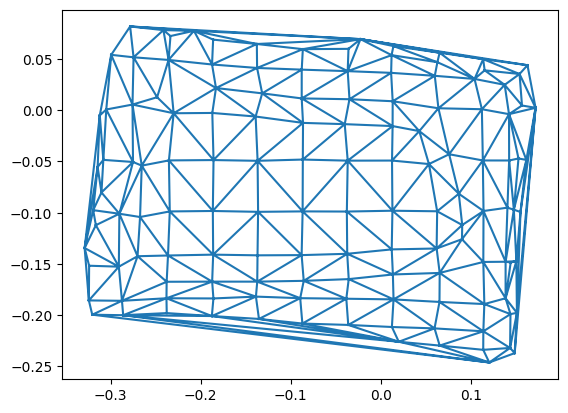

In [36]:
# Convert list to numpy array
xy_catalog = np.array(xy_catalog)

# Plot triangulation mesh
plt.triplot(xy_catalog[:,0], xy_catalog[:,1], tri.simplices)

In [37]:
# Create surface mesh
surface = o3d.geometry.TriangleMesh()

# Add vertices and triangles
surface.vertices = o3d.utility.Vector3dVector(xyz)
surface.triangles = o3d.utility.Vector3iVector(tri.simplices)

# Set mesh color
surface.paint_uniform_color([0, 0, 1.0])

# Show surface mesh
o3d.visualization.draw_geometries([surface], mesh_show_wireframe=True)

In [38]:
# Get triangle vertices from mesh
def get_triangles_vertices(triangles, vertices):
    triangles_vertices = []

    for triangle in triangles:
        new_triangles_vertices = [vertices[triangle[0]],
                                  vertices[triangle[1]],
                                  vertices[triangle[2]]]

        triangles_vertices.append(new_triangles_vertices)

    return np.array(triangles_vertices)

In [39]:
# Calculate volume under triangle
def volume_under_triangle(triangle):
    p1, p2, p3 = triangle

    x1, y1, z1 = p1
    x2, y2, z2 = p2
    x3, y3, z3 = p3

    return abs((z1+z2+z3)*(x1*y2-x2*y1+x2*y3-x3*y2+x3*y1-x1*y3)/6)

In [40]:
# Calculate total stockpile volume
volume = reduce(lambda a, b:  a + volume_under_triangle(b),
                get_triangles_vertices(surface.triangles, surface.vertices),
                0)

# Print final volume
print(f"Estimated stockpile volume: {round(volume, 4)} m3")

Estimated stockpile volume: 0.1364 m3
